# Marketing ROI Analysis Using Simple Linear Regression

## Author
Ismail Ahmad Ibrahim

## Objective
To identify the marketing channel with the strongest impact on Sales using Simple Linear Regression and provide ROI-based recommendations.

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, and regression analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## 2. Load Dataset

The marketing dataset is loaded into a Pandas DataFrame for analysis.

In [2]:
df = pd.read_csv("marketing.csv")

## 3. Data Exploration

We inspect the dataset structure, summary statistics, and missing values.

In [3]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [5]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [6]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

## 4. Data Cleaning

Missing values were identified and removed to ensure accurate model estimation.

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

## 5. Correlation Analysis

Correlation analysis helps identify the marketing channel most strongly associated with Sales.

In [9]:
df.corr(numeric_only=True)

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


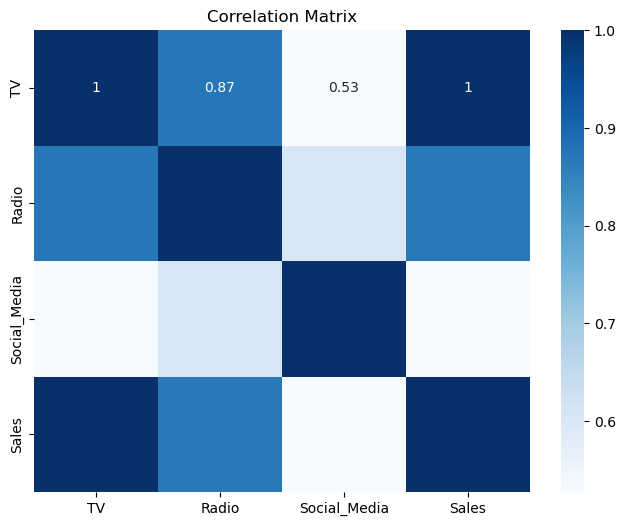

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")

plt.title("Correlation Matrix")
plt.show()

## 6. Variable Selection

TV advertising showed the strongest correlation with Sales (0.9995), making it the most suitable independent variable for Simple Linear Regression.

In [11]:
print(df.corr(numeric_only=True)["Sales"])

TV              0.999497
Radio           0.868638
Social_Media    0.527446
Sales           1.000000
Name: Sales, dtype: float64


## 7. Build Simple Linear Regression Model

An Ordinary Least Squares (OLS) regression model is fitted using TV advertising spend as the predictor variable.

In [12]:
X = df[['TV']]
X = sm.add_constant(X)

y = df['Sales']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:27:40   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## 8. Regression Diagnostics

Diagnostic plots are used to assess linearity, normality, and homoscedasticity assumptions.

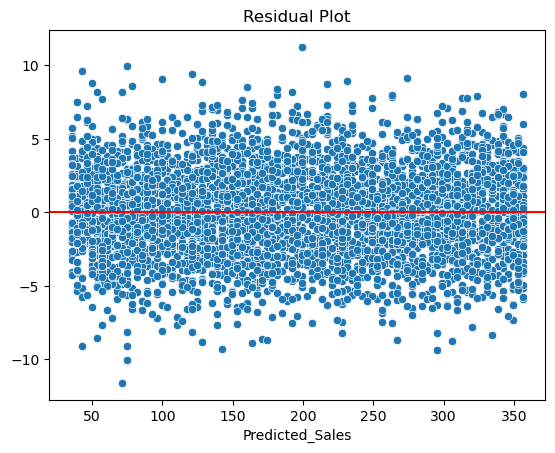

In [13]:
df['Predicted_Sales'] = model.predict(X)

residuals = y - df['Predicted_Sales']

sns.scatterplot(
    x=df['Predicted_Sales'],
    y=residuals
)

plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

### Residual Plot Interpretation

The residuals are randomly distributed around the zero line with no clear pattern or systematic structure. This indicates that the relationship between TV advertising expenditure and Sales is approximately linear.

Additionally, the spread of residuals remain constant across the range of predicted values, suggesting that the assumption of homoscedasticity is satisfied.

Therefore, the residual plot provides evidence that the linear regression model is appropriate for this dataset.

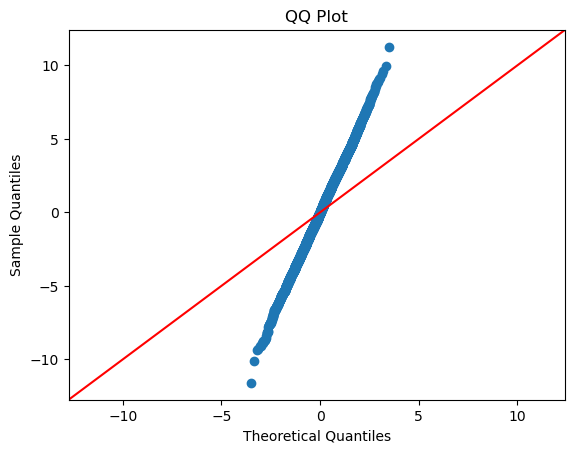

In [14]:
sm.qqplot(residuals, line='45')
plt.title("QQ Plot")
plt.show()

### QQ Plot Interpretation

The QQ plot was examined to assess the normality of residuals. Although some visual deviation from the reference line can be observed, the statistical normality tests support the assumption of normality.

The Jarque-Bera test produced a p-value of 0.985 and the Omnibus test produced a p-value of 0.974, both of which are substantially greater than 0.05.

Therefore, the residuals can be considered approximately normally distributed, satisfying the normality assumption of linear regression.

## 9. Interpretation of Results

The model achieved an R-squared value of 0.999, indicating that approximately 99.9% of the variation in Sales is explained by TV advertising expenditure.

The TV coefficient (3.5615) suggests that each additional unit spent on TV advertising is associated with an average increase of 3.56 units in Sales.

The p-value (< 0.001) confirms that TV advertising is a statistically significant predictor of Sales.

In [15]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:27:47   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## Regression Assumption Assessment

| Assumption | Assessment | Evidence |
|------------|------------|-----------|
| Linearity | Satisfied | Residuals randomly scattered around zero |
| Normality | Satisfied | Jarque-Bera p = 0.985; Omnibus p = 0.974 |
| Homoscedasticity | Satisfied | Residual spread remains approximately constant |
| Independence | Satisfied | Durbin-Watson = 1.998 |

The diagnostic checks indicate that the key assumptions of Simple Linear Regression are reasonably satisfied, supporting the validity of the model.

## 10. Business Recommendation

Based on the analysis, TV advertising should receive the highest priority in future marketing budget allocation. It demonstrated the strongest correlation with Sales and produced a highly significant regression model.

The results suggest that increasing TV advertising investment is likely to generate the highest return on investment compared to Radio and Social Media channels.